# Estimación GG — Imágenes — Mapas de Error de Predicción (rerun)

Este notebook **no reentrena las CNN**. Carga los pesos (`.pth`) ya entrenados
en `estimacion-gg-imagenes-v4` y reconstruye el mismo split train/val/test
(misma semilla) únicamente para generar **mapas de error de predicción**
sobre el mapa de Colombia, siguiendo la misma lógica que `tabular-model-rerun`.



**Ajustar antes de correr:** la variable `MODEL_DIR` debe apuntar a la ruta
(dataset de Kaggle) donde se subieron los checkpoints `modelo_resnet18.pth`,
`modelo_efficientnet_b2.pth`, `modelo_mobilenet_v3_large.pth` y
`modelo_densenet121.pth` generados por el notebook original de entrenamiento.


In [ ]:
# ==========================================
# CARGA DE MODELOS CNN ENTRENADOS (SIN REENTRENAR) Y PREPROCESAMIENTO
# ==========================================
import os
import math
import random
import numpy as np
import pandas as pd
import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models import (
    efficientnet_b2, mobilenet_v3_large, densenet121, resnet18
)
from sklearn.metrics import r2_score
from pathlib import Path
from tqdm import tqdm
from IPython.display import display


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)

# ── Rutas y parámetros (idénticos al notebook de entrenamiento) ─────────────
CSV_PATH    = Path("/kaggle/input/datasets/yapoksfrod/data-prep-clean/data_prep_clean.csv")
TIFFS_DIR   = Path("/kaggle/input/datasets/yapoksfrod/parches-geotiff-completo-v2/parches_geotiff_completo")
TARGET_SIZE = (256, 256)
BATCH_SIZE  = 16
TEST_SPLIT  = 0.10
VAL_SPLIT   = 0.10
SEED        = 42
NUM_WORKERS = 2

# Ruta a los pesos (.pth) ya entrenados de los 4 modelos CNN.
# AJUSTAR a la ruta donde subiste los checkpoints como dataset de Kaggle
# (archivos modelo_resnet18.pth, modelo_efficientnet_b2.pth,
#  modelo_mobilenet_v3_large.pth y modelo_densenet121.pth).
MODEL_DIR = Path("/kaggle/input/datasets/yapoksfrod/results-cnn-model-v4/results_cnn_model")

OUT_DIR = Path("/kaggle/working/run_comparison_imagenes")
OUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")


Dispositivo: cuda


In [ ]:
!pip install contextily --quiet

In [ ]:
# ── Carga del CSV (idéntico al entrenamiento) ────────────────────────────────
df = pd.read_csv(CSV_PATH, sep=';')
df = df.rename(columns={"Apparent Geothermal Gradient (°C/Km)": "gg"})
print(f"Total puntos : {len(df)}")
print(df[["ID", "gg"]].head())


Total puntos : 4543
   ID         gg
0   1  14.712281
1   2  21.294394
2   3  23.783404
3   4  24.156323
4   5  25.601245


In [ ]:
# ── Imputación de parches (idéntica al entrenamiento) ────────────────────────
# Necesaria para reconstruir los mismos parches de entrada que vio el modelo;
# no reentrena nada, solo prepara los datos. Si los parches imputados ya
# existen en disco, se omiten.
CARPETA_IMPUTADOS = Path("/kaggle/working/parches_imputados")
CARPETA_IMPUTADOS.mkdir(exist_ok=True)

def imputar_nearest(arr, mask):
    from scipy import ndimage as ndi
    valid = mask.astype(bool)
    if valid.all():
        return arr.astype(np.float32)
    _, inds = ndi.distance_transform_edt(~valid, return_indices=True)
    rows, cols = inds[0], inds[1]
    filled = np.empty_like(arr, dtype=np.float32)
    for b in range(arr.shape[0]):
        filled[b] = arr[b][rows, cols]
    return filled

parches_imputados = 0
parches_sin_nan   = 0
parches_error     = 0

for _, fila in tqdm(df.iterrows(), total=len(df), desc="Imputando"):
    pid         = str(fila["ID"])
    input_path  = TIFFS_DIR / f"parche_{pid}.tif"
    output_path = CARPETA_IMPUTADOS / f"parche_{pid}.tif"

    if output_path.exists():
        continue

    try:
        with rasterio.open(input_path) as src:
            arr    = src.read().astype(np.float32)
            nodata = src.nodata
            perfil = src.profile

        mask = (~np.isnan(arr).any(axis=0)).astype(np.uint8)

        if not mask.all():
            arr = np.nan_to_num(arr, nan=0.0)
            arr = imputar_nearest(arr, mask)
            parches_imputados += 1
        else:
            parches_sin_nan += 1

        perfil.update(dtype=np.float32, nodata=None)
        with rasterio.open(output_path, "w", **perfil) as dst:
            dst.write(arr)

    except Exception as e:
        print(f"Error en parche_{pid}: {e}")
        parches_error += 1

print(f"\nImputados    : {parches_imputados}")
print(f"Sin NaN      : {parches_sin_nan}")
print(f"Con error    : {parches_error}")


Imputando: 100%|██████████| 4543/4543 [05:10<00:00, 14.63it/s]


Imputados    : 1288
Sin NaN      : 3255
Con error    : 0


In [ ]:
# ── Dataset (idéntico al entrenamiento) ──────────────────────────────────────
class ParchesDataset(Dataset):
    def __init__(self, df, tiffs_dir, target_size=(256, 256), add_mask_channel=True):
        self.df               = df.reset_index(drop=True)
        self.target_h, self.target_w = target_size
        self.add_mask_channel = add_mask_channel

        tif_dict   = {f.stem.replace("parche_", ""): str(f)
                      for f in Path(tiffs_dir).glob("*.tif")}
        self.paths = [tif_dict.get(str(row["ID"])) for _, row in df.iterrows()]

        mapped = sum(1 for p in self.paths if p is not None)
        print(f"Total: {len(self.df)} | Mapeados: {mapped} | Sin mapear: {len(self.df)-mapped}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fila = self.df.iloc[idx]
        path = self.paths[idx]
        gg   = torch.tensor(float(fila["gg"]), dtype=torch.float32)

        if path is None or not os.path.exists(path):
            C = 9 + (1 if self.add_mask_channel else 0)
            return torch.zeros((C, self.target_h, self.target_w)), gg

        with rasterio.open(path) as src:
            arr    = src.read(out_dtype='float32')
            nodata = src.nodata
            if nodata is None:
                nodata = np.nan
            if np.isnan(nodata):
                mask = (~np.isnan(arr).any(axis=0)).astype(np.float32)
            else:
                mask = (np.all(arr != nodata, axis=0)).astype(np.float32)

        arr = np.nan_to_num(arr, nan=0.0)

        if self.add_mask_channel:
            arr = np.concatenate([arr, mask[np.newaxis]], axis=0)

        t = torch.from_numpy(arr)
        t = F.interpolate(t.unsqueeze(0), size=(self.target_h, self.target_w),
                          mode='bilinear', align_corners=False).squeeze(0)
        return t, gg


In [ ]:
# ── Reconstrucción del MISMO split train/val/test (misma semilla) ───────────
ds = ParchesDataset(df, str(CARPETA_IMPUTADOS), target_size=TARGET_SIZE, add_mask_channel=True)

n       = len(ds)
n_test  = int(math.ceil(n * TEST_SPLIT))
n_val   = int(math.ceil((n - n_test) * VAL_SPLIT))
n_train = n - n_test - n_val

train_ds, val_ds, test_ds = random_split(
    ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

pin = torch.cuda.is_available()
loader_test = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin)


Total: 4543 | Mapeados: 4543 | Sin mapear: 0
Train: 3679 | Val: 409 | Test: 455


In [ ]:
# ── Construcción de arquitecturas (idéntica al entrenamiento) ───────────────
sample_x, _ = ds[0]
in_ch = sample_x.shape[0]
print(f"Canales de entrada: {in_ch}")

def construir_modelo(arquitectura, in_channels, hidden=256):

    if arquitectura == "resnet18":
        model    = resnet18(weights=None)
        new_conv = nn.Conv2d(in_channels, 64, kernel_size=7,
                             stride=2, padding=3, bias=False)
        with torch.no_grad():
            avg = model.conv1.weight.data.mean(dim=1, keepdim=True)
            new_conv.weight.data = avg.repeat(1, in_channels, 1, 1) * (3.0 / float(in_channels))
        model.conv1 = new_conv
        in_feat     = model.fc.in_features
        model.fc    = nn.Sequential(
            nn.Linear(in_feat, hidden), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(hidden, 1)
        )
        class ResNetWrapper(nn.Module):
            def __init__(self, base):
                super().__init__()
                self.base = base
            def forward(self, x):
                return self.base(x).squeeze(1)
        return ResNetWrapper(model).to(device)

    elif arquitectura == "efficientnet_b2":
        model     = efficientnet_b2(weights=None)
        conv_orig = model.features[0][0]
        new_conv  = nn.Conv2d(in_channels, conv_orig.out_channels,
                              kernel_size=conv_orig.kernel_size,
                              stride=conv_orig.stride,
                              padding=conv_orig.padding, bias=False)
        with torch.no_grad():
            avg = conv_orig.weight.data.mean(dim=1, keepdim=True)
            new_conv.weight.data = avg.repeat(1, in_channels, 1, 1) * (3.0 / float(in_channels))
        model.features[0][0] = new_conv
        in_feat = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.3), nn.Linear(in_feat, hidden),
            nn.ReLU(), nn.Dropout(p=0.2), nn.Linear(hidden, 1)
        )
        class EffWrapper(nn.Module):
            def __init__(self, base):
                super().__init__()
                self.base = base
            def forward(self, x):
                return self.base(x).squeeze(1)
        return EffWrapper(model).to(device)

    elif arquitectura == "mobilenet_v3_large":
        model     = mobilenet_v3_large(weights=None)
        conv_orig = model.features[0][0]
        new_conv  = nn.Conv2d(in_channels, conv_orig.out_channels,
                              kernel_size=conv_orig.kernel_size,
                              stride=conv_orig.stride,
                              padding=conv_orig.padding, bias=False)
        with torch.no_grad():
            avg = conv_orig.weight.data.mean(dim=1, keepdim=True)
            new_conv.weight.data = avg.repeat(1, in_channels, 1, 1) * (3.0 / float(in_channels))
        model.features[0][0] = new_conv
        in_feat = model.classifier[0].in_features
        model.classifier = nn.Sequential(
            nn.Linear(in_feat, hidden), nn.Hardswish(),
            nn.Dropout(0.3), nn.Linear(hidden, 1)
        )
        class MobileWrapper(nn.Module):
            def __init__(self, base):
                super().__init__()
                self.base = base
            def forward(self, x):
                return self.base(x).squeeze(1)
        return MobileWrapper(model).to(device)

    elif arquitectura == "densenet121":
        model     = densenet121(weights=None)
        conv_orig = model.features.conv0
        new_conv  = nn.Conv2d(in_channels, conv_orig.out_channels,
                              kernel_size=conv_orig.kernel_size,
                              stride=conv_orig.stride,
                              padding=conv_orig.padding, bias=False)
        with torch.no_grad():
            avg = conv_orig.weight.data.mean(dim=1, keepdim=True)
            new_conv.weight.data = avg.repeat(1, in_channels, 1, 1) * (3.0 / float(in_channels))
        model.features.conv0 = new_conv
        in_feat = model.classifier.in_features
        model.classifier = nn.Linear(in_feat, 1)

        class DenseWrapper(nn.Module):
            def __init__(self, base):
                super().__init__()
                self.base = base
            def forward(self, x):
                f = self.base.features(x)
                f = F.relu(f, inplace=True)
                f = F.adaptive_avg_pool2d(f, (1, 1))
                f = torch.flatten(f, 1)
                return self.base.classifier(f).squeeze(1)
        return DenseWrapper(model).to(device)

    raise ValueError(f"Arquitectura no reconocida: {arquitectura}")

print("Funciones de construcción cargadas")


Canales de entrada: 10
Funciones de construcción cargadas


In [ ]:
# ── Shapefile Colombia ────────────────────────────────────────────────────────
import urllib.request, zipfile
import geopandas as gpd
from shapely.geometry import Point

def preparar_shapefile():
    shp_dir  = OUT_DIR / "colombia_shp"
    shp_dir.mkdir(parents=True, exist_ok=True)
    zip_path = shp_dir / "colombia.zip"
    shp_path = shp_dir / "ne_110m_admin_0_countries.shp"
    url      = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    if not zip_path.exists():
        urllib.request.urlretrieve(url, zip_path)
    if not shp_path.exists():
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(shp_dir)
    world = gpd.read_file(shp_path).to_crs(4326)
    for col in ["ADM0_A3", "ISO_A3", "iso_a3"]:
        if col in world.columns:
            return world[world[col] == "COL"]

colombia = preparar_shapefile()

# ── Cargar modelo YA ENTRENADO y predecir (sin reentrenar) ──────────────────
def cargar_y_predecir(arquitectura, nombre):
    model = construir_modelo(arquitectura, in_ch)
    state_path = MODEL_DIR / f"modelo_{nombre}.pth"
    model.load_state_dict(torch.load(state_path, map_location=device, weights_only=False))
    model.eval()

    pt, rt = [], []
    with torch.no_grad():
        for imgs, ggs in loader_test:
            pt.extend(model(imgs.to(device)).cpu().numpy())
            rt.extend(ggs.numpy())
    pt, rt = np.array(pt), np.array(rt)

    mse  = np.mean((pt - rt) ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(pt - rt))
    r2   = r2_score(rt, pt)
    print(f"[{nombre}] MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")
    return pt, rt, mae, rmse, r2

print("Modelos y funciones de carga listos.")


Modelos y funciones de carga listos.


In [ ]:
# ── Cargar los 4 modelos entrenados y predecir sobre el set de test ─────────
pt_resnet, rt_resnet, mae_resnet, rmse_resnet, r2_resnet = cargar_y_predecir("resnet18", "resnet18")
pt_effb2,  rt_effb2,  mae_effb2,  rmse_effb2,  r2_effb2  = cargar_y_predecir("efficientnet_b2", "efficientnet_b2")
pt_mobile, rt_mobile, mae_mobile, rmse_mobile, r2_mobile = cargar_y_predecir("mobilenet_v3_large", "mobilenet_v3_large")
pt_dense,  rt_dense,  mae_dense,  rmse_dense,  r2_dense  = cargar_y_predecir("densenet121", "densenet121")


[resnet18] MAE: 3.6549 | RMSE: 5.2027 | R²: 0.3053
[efficientnet_b2] MAE: 18.0172 | RMSE: 23.5223 | R²: -13.2012
[mobilenet_v3_large] MAE: 4.0085 | RMSE: 5.9730 | R²: 0.0843
[densenet121] MAE: 20.9642 | RMSE: 22.2943 | R²: -11.7572


In [ ]:
# ── Tabla resumen de métricas (test) ─────────────────────────────────────────
rows = [
    {"Modelo": "ResNet18",        "MAE": mae_resnet, "RMSE": rmse_resnet, "R²": r2_resnet},
    {"Modelo": "EfficientNet-B2", "MAE": mae_effb2,  "RMSE": rmse_effb2,  "R²": r2_effb2},
    {"Modelo": "MobileNetV3-L",   "MAE": mae_mobile, "RMSE": rmse_mobile, "R²": r2_mobile},
    {"Modelo": "DenseNet121",     "MAE": mae_dense,  "RMSE": rmse_dense,  "R²": r2_dense},
]
df_metricas = pd.DataFrame(rows).set_index("Modelo")
display(df_metricas.style
    .format("{:.4f}")
    .highlight_min(subset=["MAE", "RMSE"], color="lightgreen")
    .highlight_max(subset=["R²"], color="lightgreen")
    .set_caption("Métricas en test (°C/Km) — modelos CNN cargados sin reentrenar")
)


,MAE,RMSE,R²
Modelo,,,
ResNet18,3.6549,5.2027,0.3053
EfficientNet-B2,18.0172,23.5223,-13.2012
MobileNetV3-L,4.0085,5.9730,0.0843
DenseNet121,20.9642,22.2943,-11.7572


In [ ]:
# ── df_map: lat/lon + real + predicho + ERROR de predicción por modelo ──────
indices_test = test_ds.indices
df_test = df.iloc[indices_test].reset_index(drop=True)

# rt_resnet, rt_effb2, rt_mobile y rt_dense deberían ser idénticos entre sí
# (mismo test set, mismo orden, sin shuffle); se usa rt_resnet como referencia
# de los valores reales.
df_map = df_test[["Latitude", "Longitude"]].copy()
df_map["gg_real"]   = rt_resnet
df_map["gg_resnet"] = pt_resnet
df_map["gg_effb2"]  = pt_effb2
df_map["gg_mobile"] = pt_mobile
df_map["gg_dense"]  = pt_dense

# Error = predicho - real  (positivo -> sobreestimacion, negativo -> subestimacion)
df_map["err_resnet"] = df_map["gg_resnet"] - df_map["gg_real"]
df_map["err_effb2"]  = df_map["gg_effb2"]  - df_map["gg_real"]
df_map["err_mobile"] = df_map["gg_mobile"] - df_map["gg_real"]
df_map["err_dense"]  = df_map["gg_dense"]  - df_map["gg_real"]

# ── Escala simetrica para el mapa de error (percentil 95 global) ─────────────
# p95 sobre los 4 modelos: escala compartida para comparabilidad visual.
# Outliers extremos quedan saturados en el color máximo (extend="both").
all_errors = pd.concat([
    df_map["err_resnet"], df_map["err_effb2"],
    df_map["err_mobile"], df_map["err_dense"]
])
max_abs = np.ceil(np.percentile(all_errors.abs(), 95))
print(f"Rango simétrico del error (p95 global): ±{max_abs:.1f} °C/Km")
print(f"  (máximo absoluto real: ±{all_errors.abs().max():.1f} °C/Km, saturado en colorbar)")

# Colormap para error: azul -> blanco (0) -> rojo
cmap_err = plt.cm.RdBu_r
norm_err = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)

print("Setup geoespacial listo.")


Rango simétrico del error (p95 global): ±28.0 °C/Km
  (máximo absoluto real: ±312.6 °C/Km, saturado en colorbar)
Setup geoespacial listo.


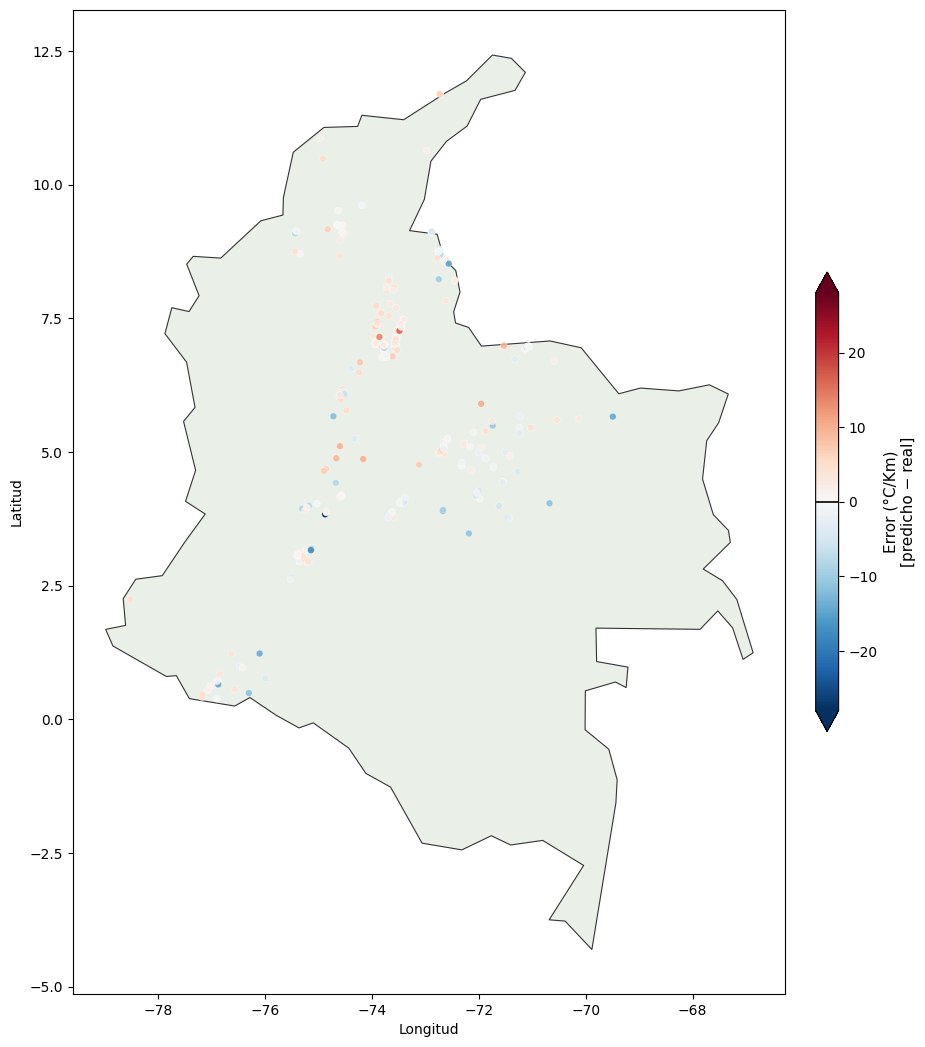

Guardado: mapa_error_resnet18_sinctx.png / .pdf


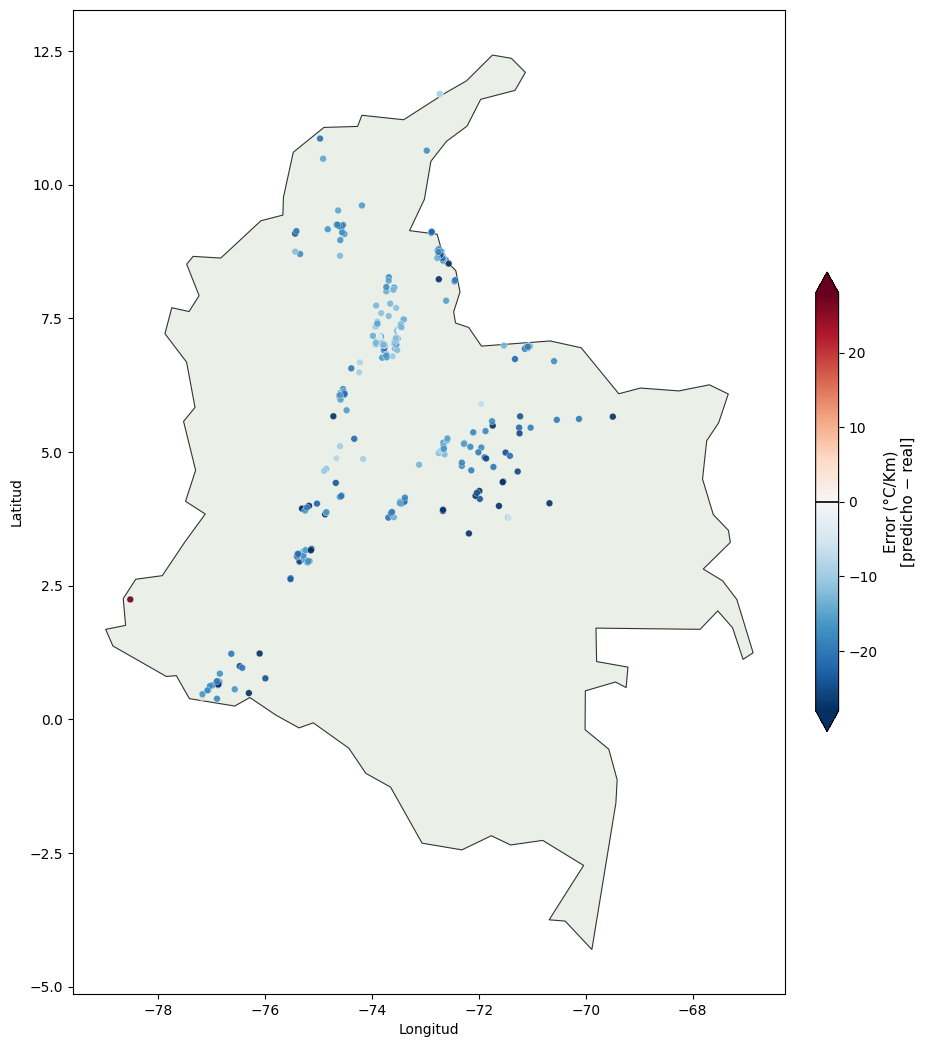

Guardado: mapa_error_efficientnetb2_sinctx.png / .pdf


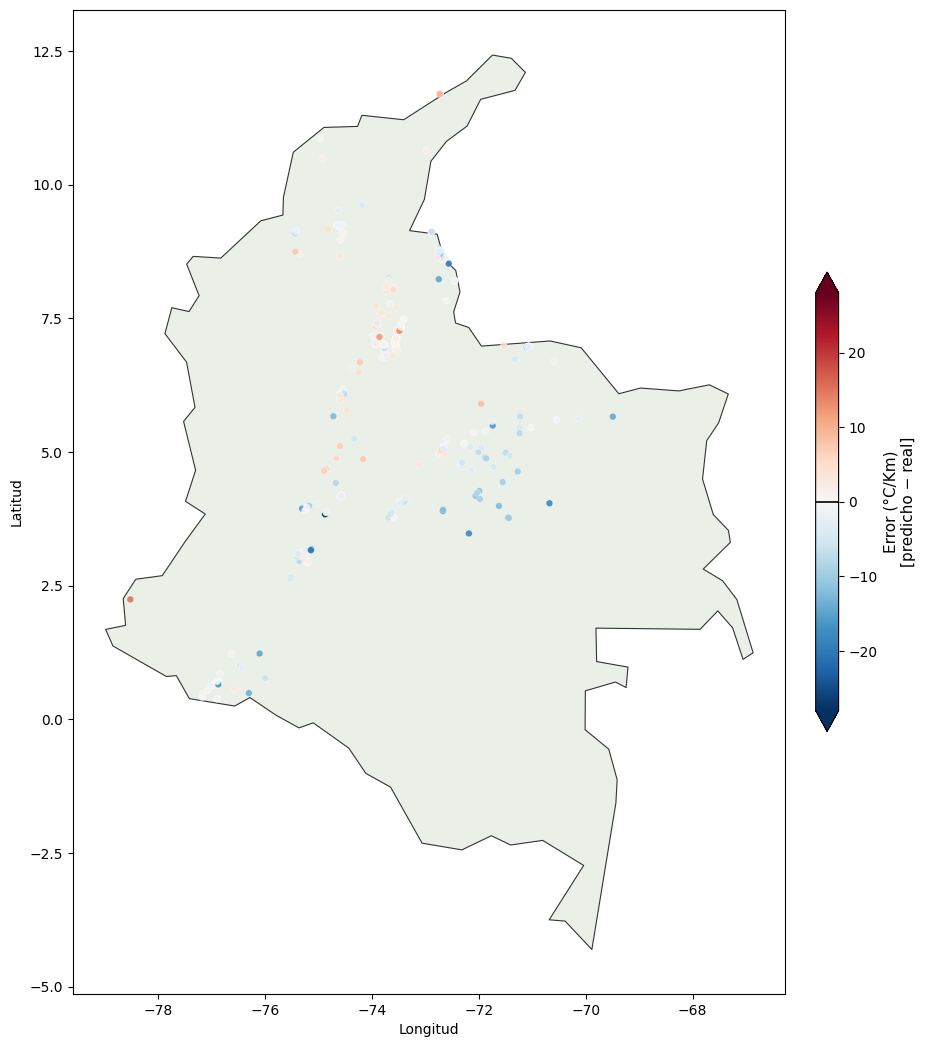

Guardado: mapa_error_mobilenetv3l_sinctx.png / .pdf


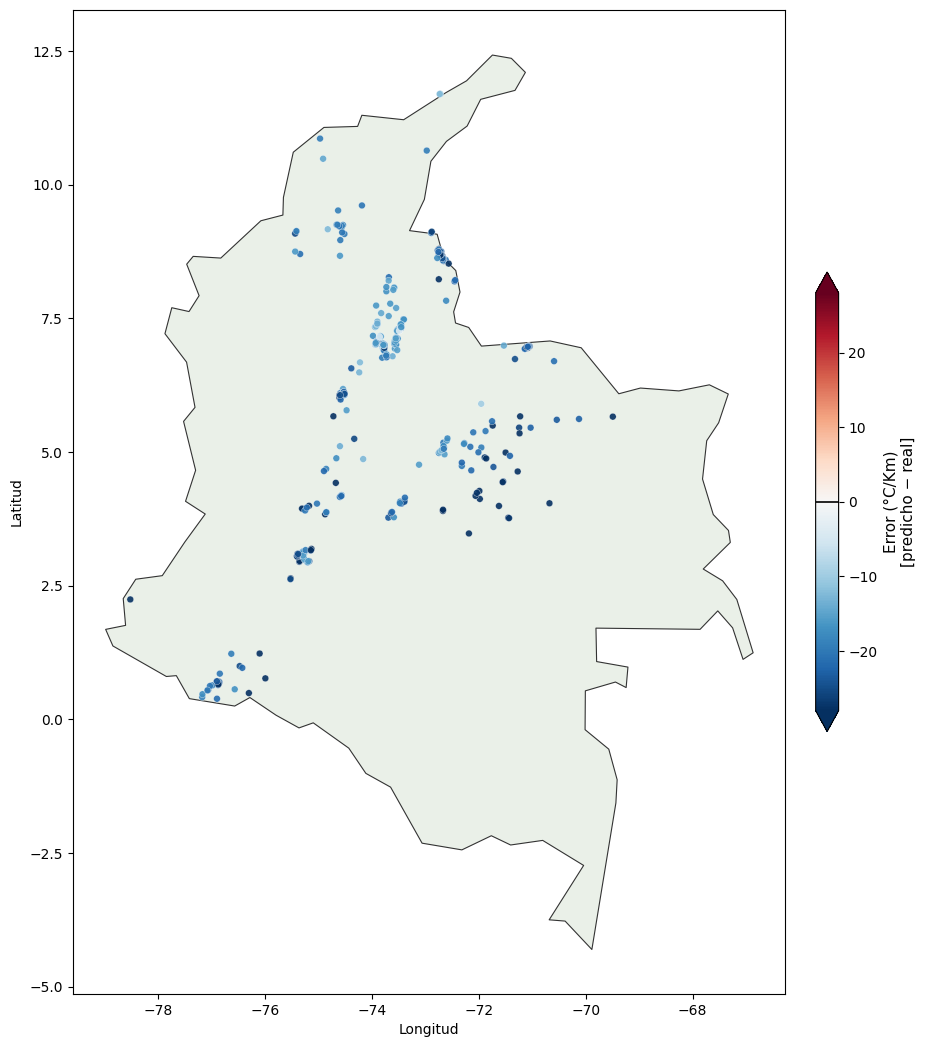

Guardado: mapa_error_densenet121_sinctx.png / .pdf


In [ ]:
# ── Mapas de error SIN basemap (guardados sin título dibujado) ──────────────
def plot_mapa_error_sin_ctx(col_error, titulo, filename):
    gdf = gpd.GeoDataFrame(
        df_map[[col_error]].copy(),
        geometry=[Point(xy) for xy in zip(df_map["Longitude"], df_map["Latitude"])],
        crs="EPSG:4326"
    )
    fig, ax = plt.subplots(figsize=(9, 11))
    colombia.plot(ax=ax, color="#eaf0e8", edgecolor="#333333", linewidth=0.8)
    gdf.plot(
        column=col_error, cmap=cmap_err, norm=norm_err,
        markersize=24, alpha=0.90, edgecolor="white",
        linewidth=0.25, legend=False, ax=ax,
    )
    sm   = cm.ScalarMappable(cmap=cmap_err, norm=norm_err)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04, extend="both")
    cbar.set_label("Error (°C/Km)\n[predicho − real]", fontsize=11)
    cbar.ax.axhline(y=0, color="black", linewidth=1.2)
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
    ax.set_aspect("equal")
    plt.tight_layout()
    fig.savefig(OUT_DIR / f"{filename}.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUT_DIR / f"{filename}.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Guardado: {filename}.png / .pdf")

plot_mapa_error_sin_ctx("err_resnet", "Error de Predicción — ResNet18 (°C/Km)",          "mapa_error_resnet18_sinctx")
plot_mapa_error_sin_ctx("err_effb2",  "Error de Predicción — EfficientNet-B2 (°C/Km)",   "mapa_error_efficientnetb2_sinctx")
plot_mapa_error_sin_ctx("err_mobile", "Error de Predicción — MobileNetV3-Large (°C/Km)", "mapa_error_mobilenetv3l_sinctx")
plot_mapa_error_sin_ctx("err_dense",  "Error de Predicción — DenseNet121 (°C/Km)",       "mapa_error_densenet121_sinctx")


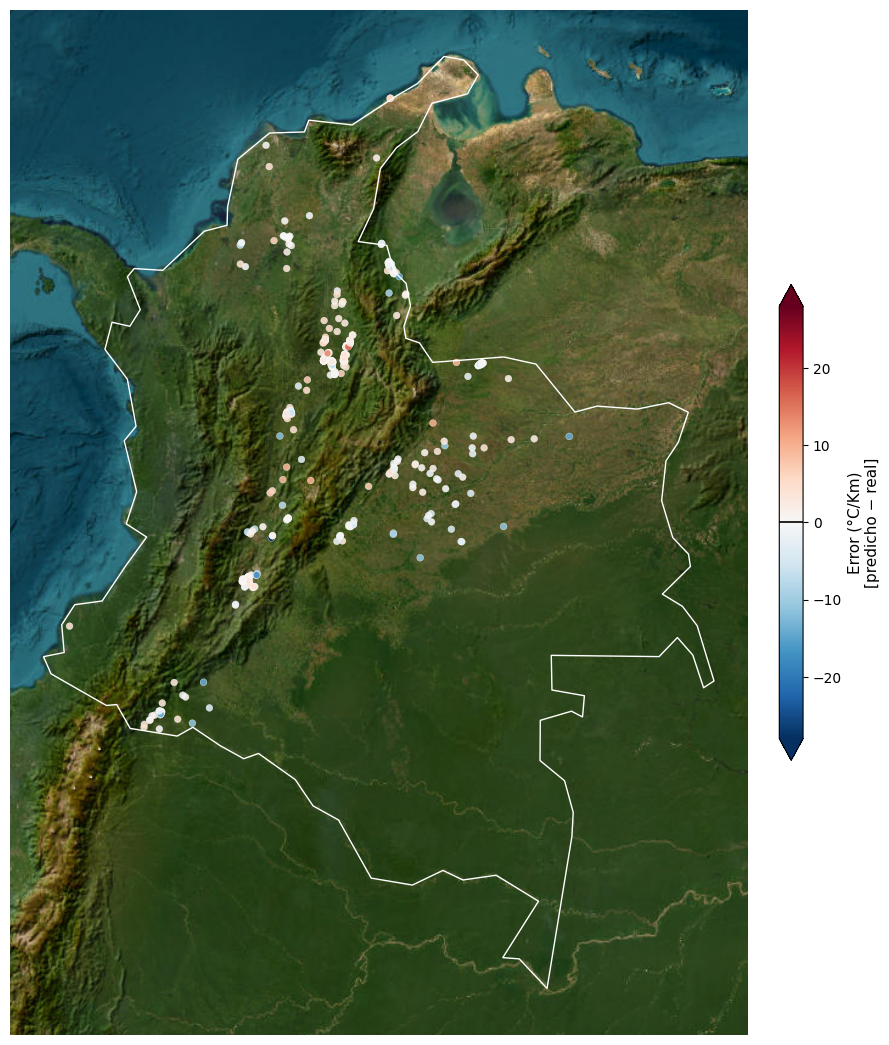

Guardado: mapa_error_resnet18_ctx.png / .pdf


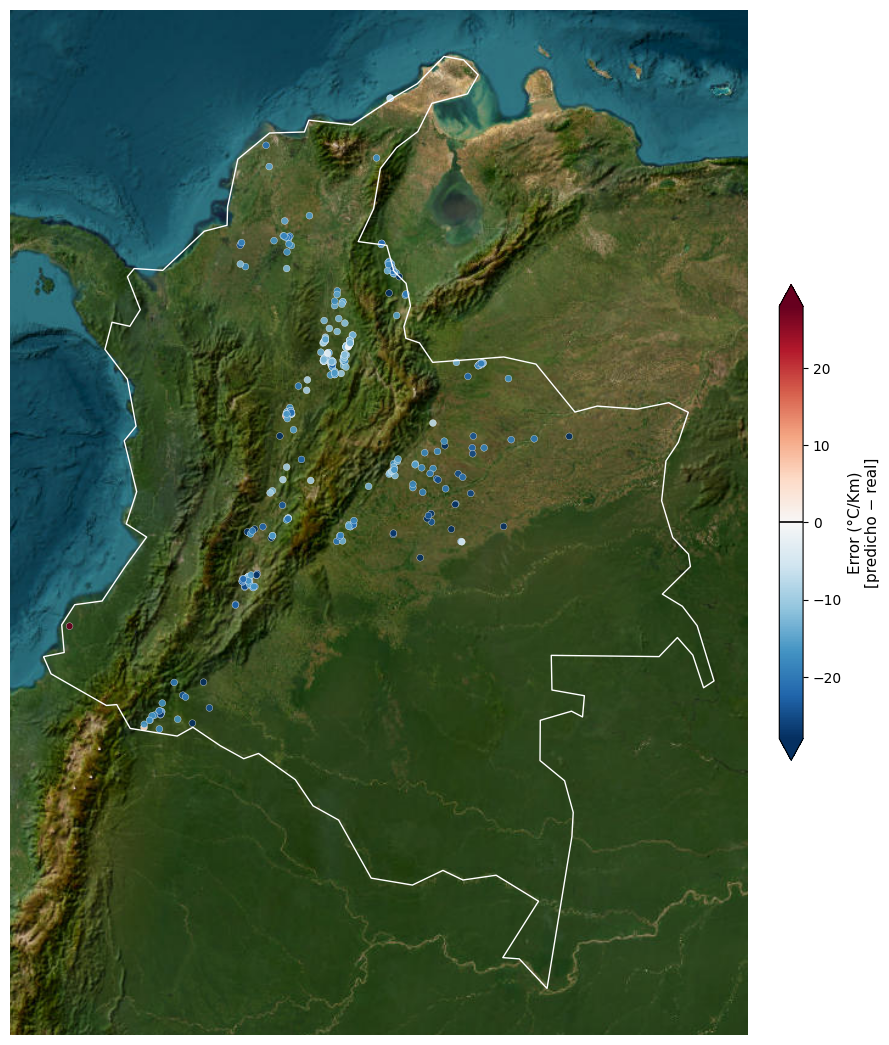

Guardado: mapa_error_efficientnetb2_ctx.png / .pdf


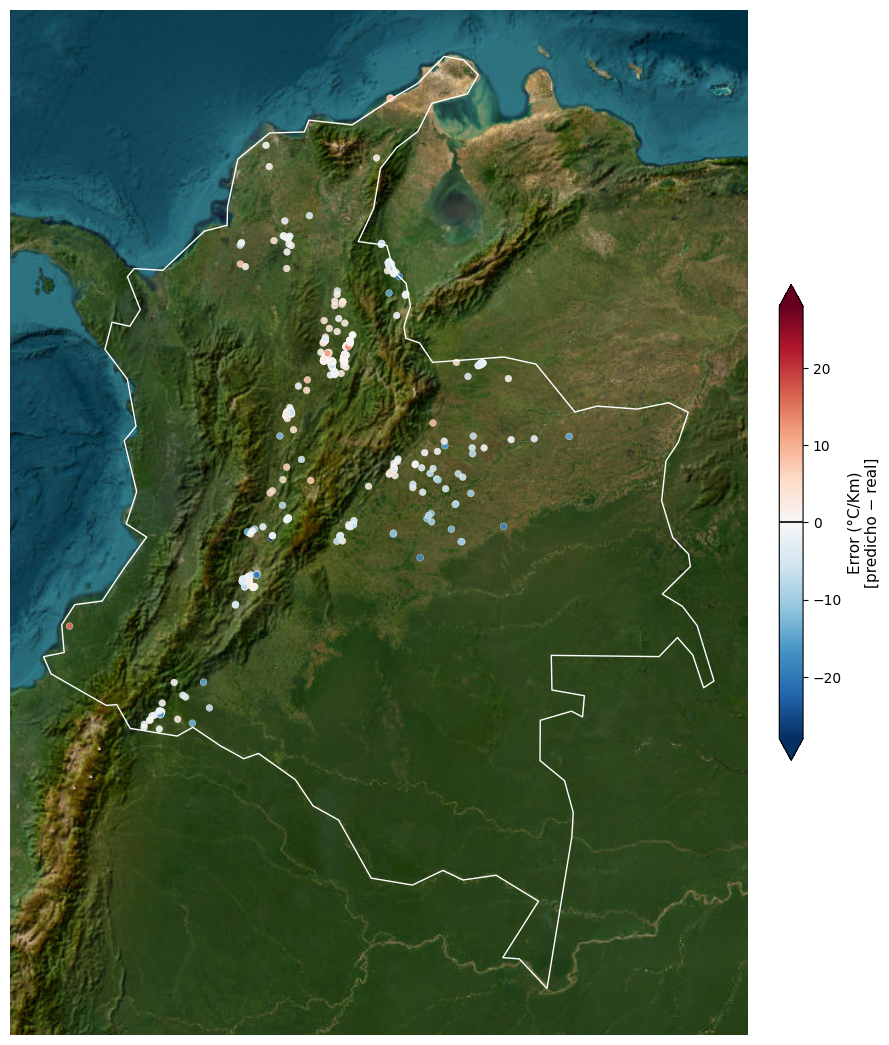

Guardado: mapa_error_mobilenetv3l_ctx.png / .pdf


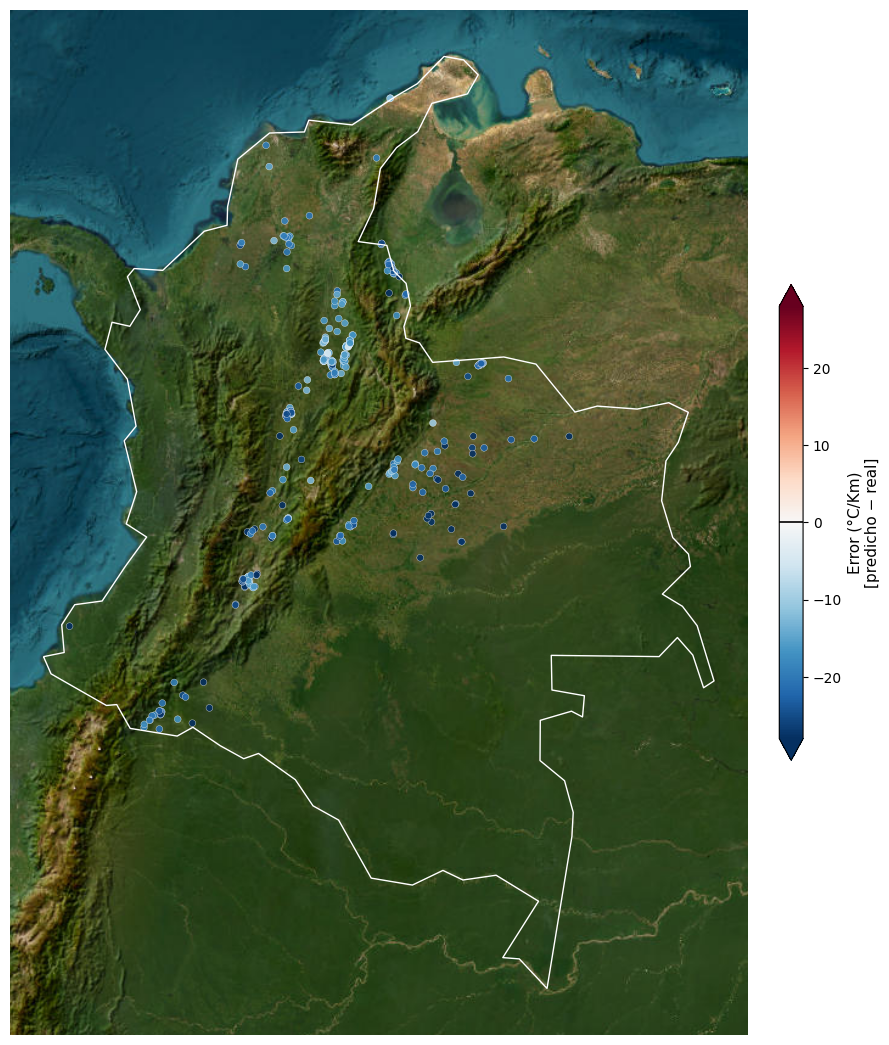

Guardado: mapa_error_densenet121_ctx.png / .pdf


In [ ]:
# ── Mapas de error CON basemap satelital (guardados sin título dibujado) ────
try:
    import contextily as ctx
    HAS_CTX = True
except ImportError:
    HAS_CTX = False
    print("contextily no disponible")

def plot_mapa_error_con_ctx(col_error, titulo, filename):
    if not HAS_CTX:
        print("contextily no disponible, usando versión sin basemap.")
        plot_mapa_error_sin_ctx(col_error, titulo, filename)
        return

    gdf = gpd.GeoDataFrame(
        df_map[[col_error]].copy(),
        geometry=[Point(xy) for xy in zip(df_map["Longitude"], df_map["Latitude"])],
        crs="EPSG:4326"
    )
    gdf_web      = gdf.to_crs(epsg=3857)
    colombia_web = colombia.to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(9, 11))
    colombia_web.boundary.plot(ax=ax, color="white", linewidth=1.0)
    gdf_web.plot(
        column=col_error, cmap=cmap_err, norm=norm_err,
        markersize=24, alpha=0.90, edgecolor="white",
        linewidth=0.25, legend=False, ax=ax,
    )
    try:
        ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, attribution=False)
    except Exception:
        ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap, attribution=False)

    sm   = cm.ScalarMappable(cmap=cmap_err, norm=norm_err)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04, extend="both")
    cbar.set_label("Error (°C/Km)\n[predicho − real]", fontsize=11)
    cbar.ax.axhline(y=0, color="black", linewidth=1.2)

    ax.set_axis_off()
    plt.tight_layout()
    fig.savefig(OUT_DIR / f"{filename}.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUT_DIR / f"{filename}.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Guardado: {filename}.png / .pdf")

plot_mapa_error_con_ctx("err_resnet", "Error de Predicción — ResNet18 (°C/Km)",          "mapa_error_resnet18_ctx")
plot_mapa_error_con_ctx("err_effb2",  "Error de Predicción — EfficientNet-B2 (°C/Km)",   "mapa_error_efficientnetb2_ctx")
plot_mapa_error_con_ctx("err_mobile", "Error de Predicción — MobileNetV3-Large (°C/Km)", "mapa_error_mobilenetv3l_ctx")
plot_mapa_error_con_ctx("err_dense",  "Error de Predicción — DenseNet121 (°C/Km)",       "mapa_error_densenet121_ctx")
